In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df = pd.read_csv("synthetic_vitals_dataset_conditioned.csv")

In [19]:
df.head()

,age,bloodGroup,hasBpHigh,hasBpLow,gender,height,hasDiabetes,weight,heartRate,SpO2,temperature,label
0,85,AB+,0,1,Other,151.521777,1,108.382099,87.233788,99.766032,37.898542,abnormal
1,31,AB-,0,1,Female,163.157347,0,90.917069,89.183565,95.837871,35.591141,abnormal
2,60,AB-,1,0,Female,163.245305,1,51.833201,86.517810,97.214998,37.274909,normal
3,29,O+,0,1,Male,167.219274,1,57.782171,99.257041,99.467769,36.292006,normal
4,61,AB+,1,1,Female,173.011174,1,60.924715,69.880261,95.568296,36.717297,normal


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          5000 non-null   int64  
 1   bloodGroup   5000 non-null   object 
 2   hasBpHigh    5000 non-null   int64  
 3   hasBpLow     5000 non-null   int64  
 4   gender       5000 non-null   object 
 5   height       5000 non-null   float64
 6   hasDiabetes  5000 non-null   int64  
 7   weight       5000 non-null   float64
 8   heartRate    5000 non-null   float64
 9   SpO2         5000 non-null   float64
 10  temperature  5000 non-null   float64
 11  label        5000 non-null   object 
dtypes: float64(5), int64(4), object(3)
memory usage: 468.9+ KB


In [21]:
df.describe()

,age,hasBpHigh,hasBpLow,height,hasDiabetes,weight,heartRate,SpO2,temperature
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,45.131400,0.510400,0.495800,164.891806,0.498600,70.284254,79.966648,96.968236,36.798951
std,25.474032,0.499942,0.500032,9.882834,0.500048,15.063744,14.996198,1.880880,0.489487
min,1.000000,0.000000,0.000000,140.000000,0.000000,40.000000,30.000000,89.138480,35.098228
25%,23.000000,0.000000,0.000000,158.079106,0.000000,59.949838,69.825982,95.667448,36.470466
50%,45.000000,1.000000,0.000000,164.914273,0.000000,70.033079,80.010216,97.034354,36.798739
75%,67.000000,1.000000,1.000000,171.583018,1.000000,80.467795,90.137379,98.380334,37.133829
max,89.000000,1.000000,1.000000,195.454763,1.000000,127.435129,134.261925,100.000000,38.420930


In [22]:
df["label"].value_counts()

label
normal      3075
abnormal    1925
Name: count, dtype: int64

In [23]:
X = df.drop("label", axis=1)
y = df["label"].map({"normal": 0, "abnormal": 1})

In [24]:
print(X)

      age bloodGroup  hasBpHigh  hasBpLow  gender      height  hasDiabetes  \
0      85        AB+          0         1   Other  151.521777            1   
1      31        AB-          0         1  Female  163.157347            0   
2      60        AB-          1         0  Female  163.245305            1   
3      29         O+          0         1    Male  167.219274            1   
4      61        AB+          1         1  Female  173.011174            1   
...   ...        ...        ...       ...     ...         ...          ...   
4995   66        AB-          1         1  Female  180.505375            1   
4996   37        AB+          1         0    Male  160.912781            1   
4997   51         B-          0         0   Other  168.038899            1   
4998   17         B-          1         1   Other  163.342610            1   
4999   35         A-          1         0    Male  162.811779            0   

          weight   heartRate       SpO2  temperature  
0     10

In [25]:
print(y)

0       1
1       1
2       0
3       0
4       0
       ..
4995    0
4996    1
4997    0
4998    1
4999    1
Name: label, Length: 5000, dtype: int64


In [26]:
y.value_counts()

label
0    3075
1    1925
Name: count, dtype: int64

In [27]:
numeric_features = ['age', 'height', 'weight', 'heartRate', 'SpO2', 'temperature']
categorical_features = ['bloodGroup', 'gender']
boolean_features = ['hasBpHigh', 'hasBpLow', 'hasDiabetes']

In [28]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(), categorical_features),
    ('bool', 'passthrough', boolean_features)
])

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

In [30]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [31]:
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'height', 'weight',
                                                   'heartRate', 'SpO2',
                                                   'temperature']),
                                                 ('cat', OneHotEncoder(),
                                                  ['bloodGroup', 'gender']),
                                                 ('bool', 'passthrough',
                                                  ['hasBpHigh', 'hasBpLow',
                                                   'hasDiabetes'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [32]:
y_pred_rf = rf_pipeline.predict(X_test)

In [33]:
print("Random Forest Results:")
print(classification_report(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Results:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       615
           1       0.98      0.99      0.99       385

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000

Accuracy: 0.99


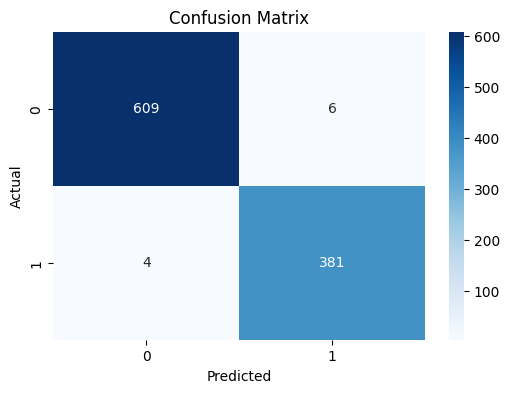

In [44]:
conf_matrix = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [45]:
import joblib

joblib.dump(rf_pipeline, "vitals_rf_model.pkl")

['vitals_rf_model.pkl']